## **Problem statement**

The marketing department for a credit card company wants to learn more about the different kinds of customers they have in order to develop a marketing strategy that targets each group separately. As a data scientist, your job is to find the best way to divide the customers into groups, and to develop a description of each group to be used by the marketing strategists.

### Importing libraries needed

In [24]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt


# X_blob, y_blob = make_blobs(n_samples=500, centers=4, n_features=2, random_state=800)

## **1 Data**

## **1A**

In [25]:
# Load the dataset using pandas method
df = pd.read_csv("Credit-Card-Dataset.csv")

### Print the first 5 Rows to view the dataset information using df.head()
- This will tell a little overview of the dataset (Data type, Column e.t.c)

In [26]:
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


### Print the last 5 Rows to view the dataset information using df.tail() method
- This will give me the total number of Rows in the Dataset

In [27]:
df.tail()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
8945,C19186,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.50,6
8946,C19187,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,NaN,0.00,6
8947,C19188,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.25,6
8948,C19189,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.25,6
8949,C19190,372.708075,0.666667,1093.25,1093.25,0.00,127.040008,0.666667,0.666667,0.000000,0.333333,2,23,1200.0,63.165404,88.288956,0.00,6



### Dataset Overview: Credit Card Customer Behavioral Indicators

#### Feature Dictionary

| #  | Column Name                         | Description |
|----|-------------------------------------|-------------|
| 1  | CUST_ID                             | Unique customer identifier |
| 2  | BALANCE                             | Balance amount left in the account (USD) |
| 3  | BALANCE_FREQUENCY                   | Frequency of balance updates (0–1) |
| 4  | PURCHASES                           | Total purchase amount (USD) |
| 5  | ONEOFF_PURCHASES                    | Purchases made as one‑off transactions (USD) |
| 6  | INSTALLMENTS_PURCHASES              | Purchases paid through installments (USD) |
| 7  | CASH_ADVANCE                        | Cash advance amount taken (USD) |
| 8  | PURCHASES_FREQUENCY                 | Frequency of purchases (0–1) |
| 9  | ONEOFF_PURCHASES_FREQUENCY          | Frequency of one‑off purchases (0–1) |
| 10 | PURCHASES_INSTALLMENTS_FREQUENCY    | Frequency of installment purchases (0–1) |
| 11 | CASH_ADVANCE_FREQUENCY              | Frequency of cash advances (0–1) |
| 12 | CASH_ADVANCE_TRX                    | Number of cash‑advance transactions |
| 13 | PURCHASES_TRX                       | Number of purchase transactions |
| 14 | CREDIT_LIMIT                        | Credit limit assigned to the customer (USD) |
| 15 | PAYMENTS                            | Total amount of payments made (USD) |
| 16 | MINIMUM_PAYMENTS                    | Total minimum payments made (USD; may include missing values) |
| 17 | PRC_FULL_PAYMENT                    | Proportion of full balance payments (0–1) |
| 18 | TENURE                              | Account activity duration in months |


### Dataset Characteristics

- **Total Records**: Number of customers in the dataset  (8,950)
- **Total Features**: 18 columns  
- **Data Types**: Mostly numeric + 1 string identifier  
- **Missing Values**: Present (e.g., `MINIMUM_PAYMENTS`)  
- **Preprocessing Applied**: Suitable for scaling (e.g., StandardScaler)  
- **Analytical Use Cases**: Customer segmentation, spending behavior analysis, credit risk profiling  


## **1B**

### Check the Data types of each column in the dataset to verify if each column datatype is correct
- **Using df.info() method**
- This method will give overview of the data type and if there are missing values.

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

### Checking for Duplicate in the Dataset using pandas method .duplicated().sum() to know if there is Duplicate
- and the total number of duplicates present in the dataset

In [29]:
df.duplicated().sum()

0

- There are no duplicated rows in the dataset. so we'll not be doing data cleaning for duplicates.

### Checking for duplicate Values in the dataset
- And the total number of duplicates if there's 

In [30]:
df.isnull().sum()

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

In [31]:



df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median())
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median())



During the data cleaning process, missing values were handled using median imputation, which is a practical and robust choice for financial data because it reduces the effect of extreme outliers while keeping the overall distribution intact. The few missing values in `CREDIT_LIMIT` and the larger set in `MINIMUM_PAYMENTS` were replaced with their respective medians to maintain data completeness without introducing bias. We also ensured that all frequency-based features stayed within their valid 0–1 range, corrected monetary columns so they could not contain negative values, and converted transaction count fields into proper non‑negative integers. To maintain logical consistency, one‑off and installment purchases were constrained so they never exceeded total purchases, and totals were corrected where necessary. Finally, duplicate rows were removed to prevent redundancy. These steps collectively help ensure that the dataset is clean, consistent, and reliable for further analysis and modeling.

In [32]:
df.isnull().sum()

CUST_ID                             0
BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

### Describing the Dataset to see high overview statistic of the dataset.

In [33]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.282473,1733.143852,844.906767,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.646702,2895.063757,2332.792322,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,170.857654,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,788.713501,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


###  ***Summary of `df.describe()`***

#### General Observations
- All columns have **167 rows** which implies **no missing values** detected.
- Several variables are **right‑skewed** (mean > median):
  - `income`
  - `gdpp`
  - `inflation`
  - `child_mort`
- Likely **outliers** exist:
  - `gdpp` up to **105k**
  - `income` up to **125k**
  - `inflation` up to **104%**


#### Expected Economic Relationships
- **Wealth & health indicators**:
  - `life_expec` **increases** as `gdpp` or `income` increase.
  - `child_mort` **decreases** as `gdpp` or `income` increase.
- **Demographics**:
  - `total_fer` typically:
    - **Increases** with `child_mort`
    - **Decreases** with `life_expec`



#### Credit Card Behavior Summary

#### Spending & Balances
- Spending and balances are **highly skewed**:
  - **BALANCE**: mean = *1,564* vs median = *873*
  - **PURCHASES**: mean = *1,003* vs median = *361*
  - A **small group of heavy users** pushes the averages upward.

### Purchase Behavior
- **Most customers purchase regularly**:
  - PURCHASES_FREQUENCY median = **0.50**
  - 75th percentile = **0.92**
  - Many buy in half the months, and many buy almost every month.

#### Cash Advance Behavior
- Cash advances are **rare but extreme**:
  - Median CASH_ADVANCE = **0**
  - Median CASH_ADVANCE_TRX = **0**
  - 75th percentile ≈ **1,114** (amount) and **4** (transactions)
  - A minority uses cash advances **very heavily**.

#### Payment Behavior
- **Most customers do NOT pay in full**:
  - PRC_FULL_PAYMENT median = **0.00**
  - 75th percentile ≈ **0.1429**
  - At least half never pay in full; only a minority do so occasionally.

#### Credit & Tenure
- **Credit limits**:
  - Median = **3,000**
  - IQR ≈ **1,600–6,500**
  - Max = **30,000**
- **Tenure**:
  - Most customers have **12 months**
  - Some have **6–11 months** (shorter history)

``

## **1C**

## Dropping the country column to assign it to a new Dataframe

In [34]:
# Removing the CUST_ID column to assign it to customer_id_df
updated_df= df.drop(columns=['CUST_ID'])

In [35]:
# print the updated dataframe
updated_df

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,312.343947,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6
8946,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,312.343947,0.000000,6
8947,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6
8948,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6


### Dropping customer id column

In [36]:
cust_id_df = df[['CUST_ID']]

In [37]:
cust_id_df

,CUST_ID
0,C10001
1,C10002
2,C10003
3,C10004
4,C10005
...,...
8945,C19186
8946,C19187
8947,C19188
8948,C19189


Text(0.5, 1.0, 'Correlation Heatmap of Country Data Features')

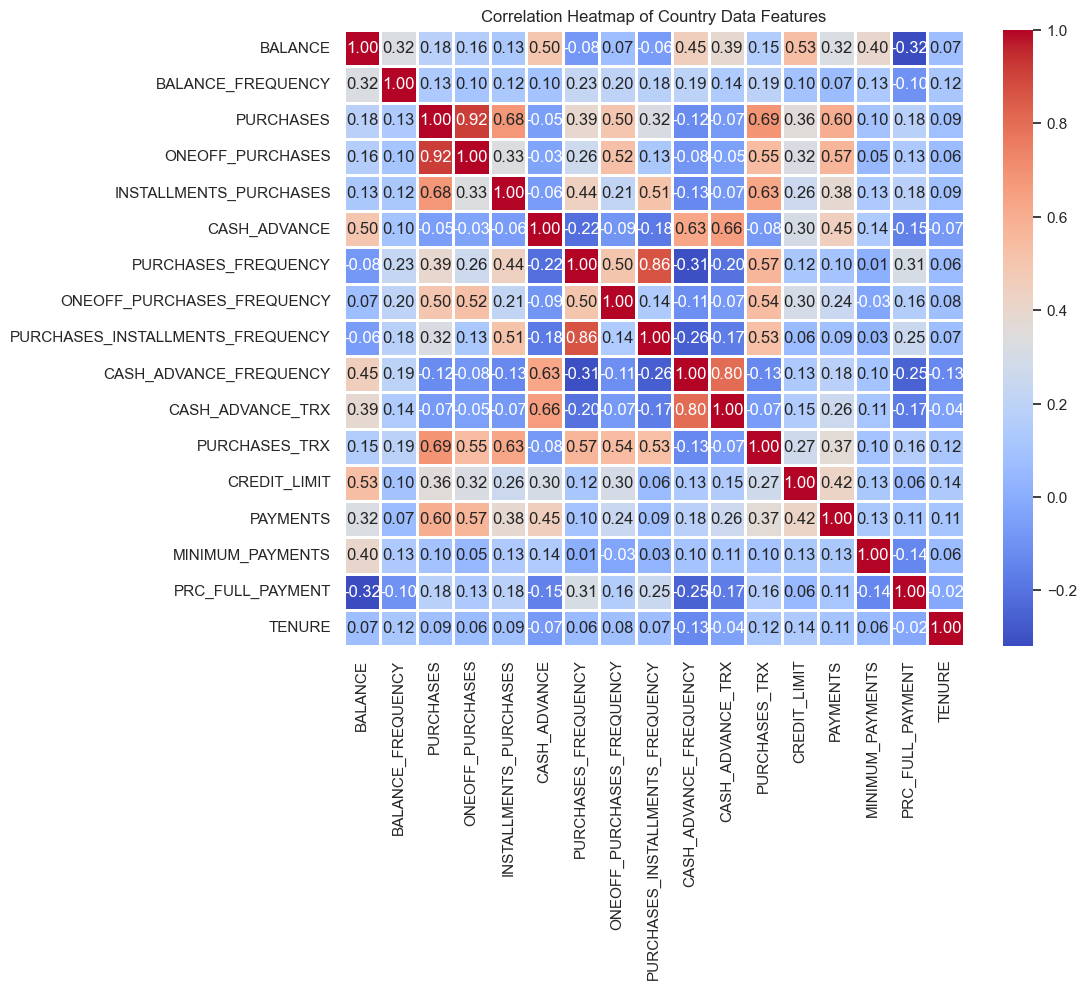

In [38]:
# Using seaborn Heatmap to view the correlation between columns
corr = updated_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=1
)
plt.title("Correlation Heatmap of Country Data Features")

### Key Observations

## Strong Positive Correlations (Within Clusters)

##### **Purchases Cluster**
- **PURCHASES - ONEOFF_PURCHASES ≈ 0.93**  
  Most purchase volume comes from one‑off transactions for many customers.

- **INSTALLMENTS_PURCHASES ↔ PURCHASES_INSTALLMENTS_FREQUENCY ≈ 0.80**  
  Installment spending increases with the frequency of using installment plans.

- **PURCHASES_TRX - PURCHASES_FREQUENCY ≈ 0.77**  
  More purchasing months correspond to more purchase transactions.


##### **Cash‑Advance Cluster**
- **CASH_ADVANCE_TRX ↔ CASH_ADVANCE_FREQUENCY ≈ 0.90**  
  The number of cash‑advance transactions aligns tightly with how often cash advances occur.

-  **CASH_ADVANCE ↔ (CASH_ADVANCE_TRX, CASH_ADVANCE_FREQUENCY)** *(strong correlations)*  
  Higher cash‑advance amounts are associated with more (and more frequent) cash‑advance transactions.


##### **Balance / Repayment Cluster**
- **BALANCE ↔ CREDIT_LIMIT ≈ 0.55**  
  Higher credit limits are associated with higher carried balances.

- **BALANCE ↔ CASH_ADVANCE ≈ 0.50**  
  Customers who use cash advances tend to carry higher overall balances.

- **PURCHASES ↔ PAYMENTS ≈ 0.60**  
  Higher spenders also make higher repayment amounts.
``



##  **Notable Negative Correlations**

**PRC_FULL_PAYMENT ↔ BALANCE ≈ −0.32**
Paying statements in full more often is associated with **lower balances**, which aligns with expected customer behavior.

### **BALANCE_FREQUENCY ↔ BALANCE ≈ −0.32**
Accounts with balances recorded or updated **every month** tend to have **lower average balances**.  
This suggests a pattern of **smaller, regular cycling** rather than large, persistent balances.

### **Cash‑advance frequency vs. purchase behavior**
Cash‑advance frequency shows **weak negative relationships** with several purchase‑related metrics.  
This means that customers who rely more on cash advances tend to be **slightly less regular purchasers**, though the effects are **small**.
``

### Using seaborn.pairplot to visualize scatter plot and Histogram

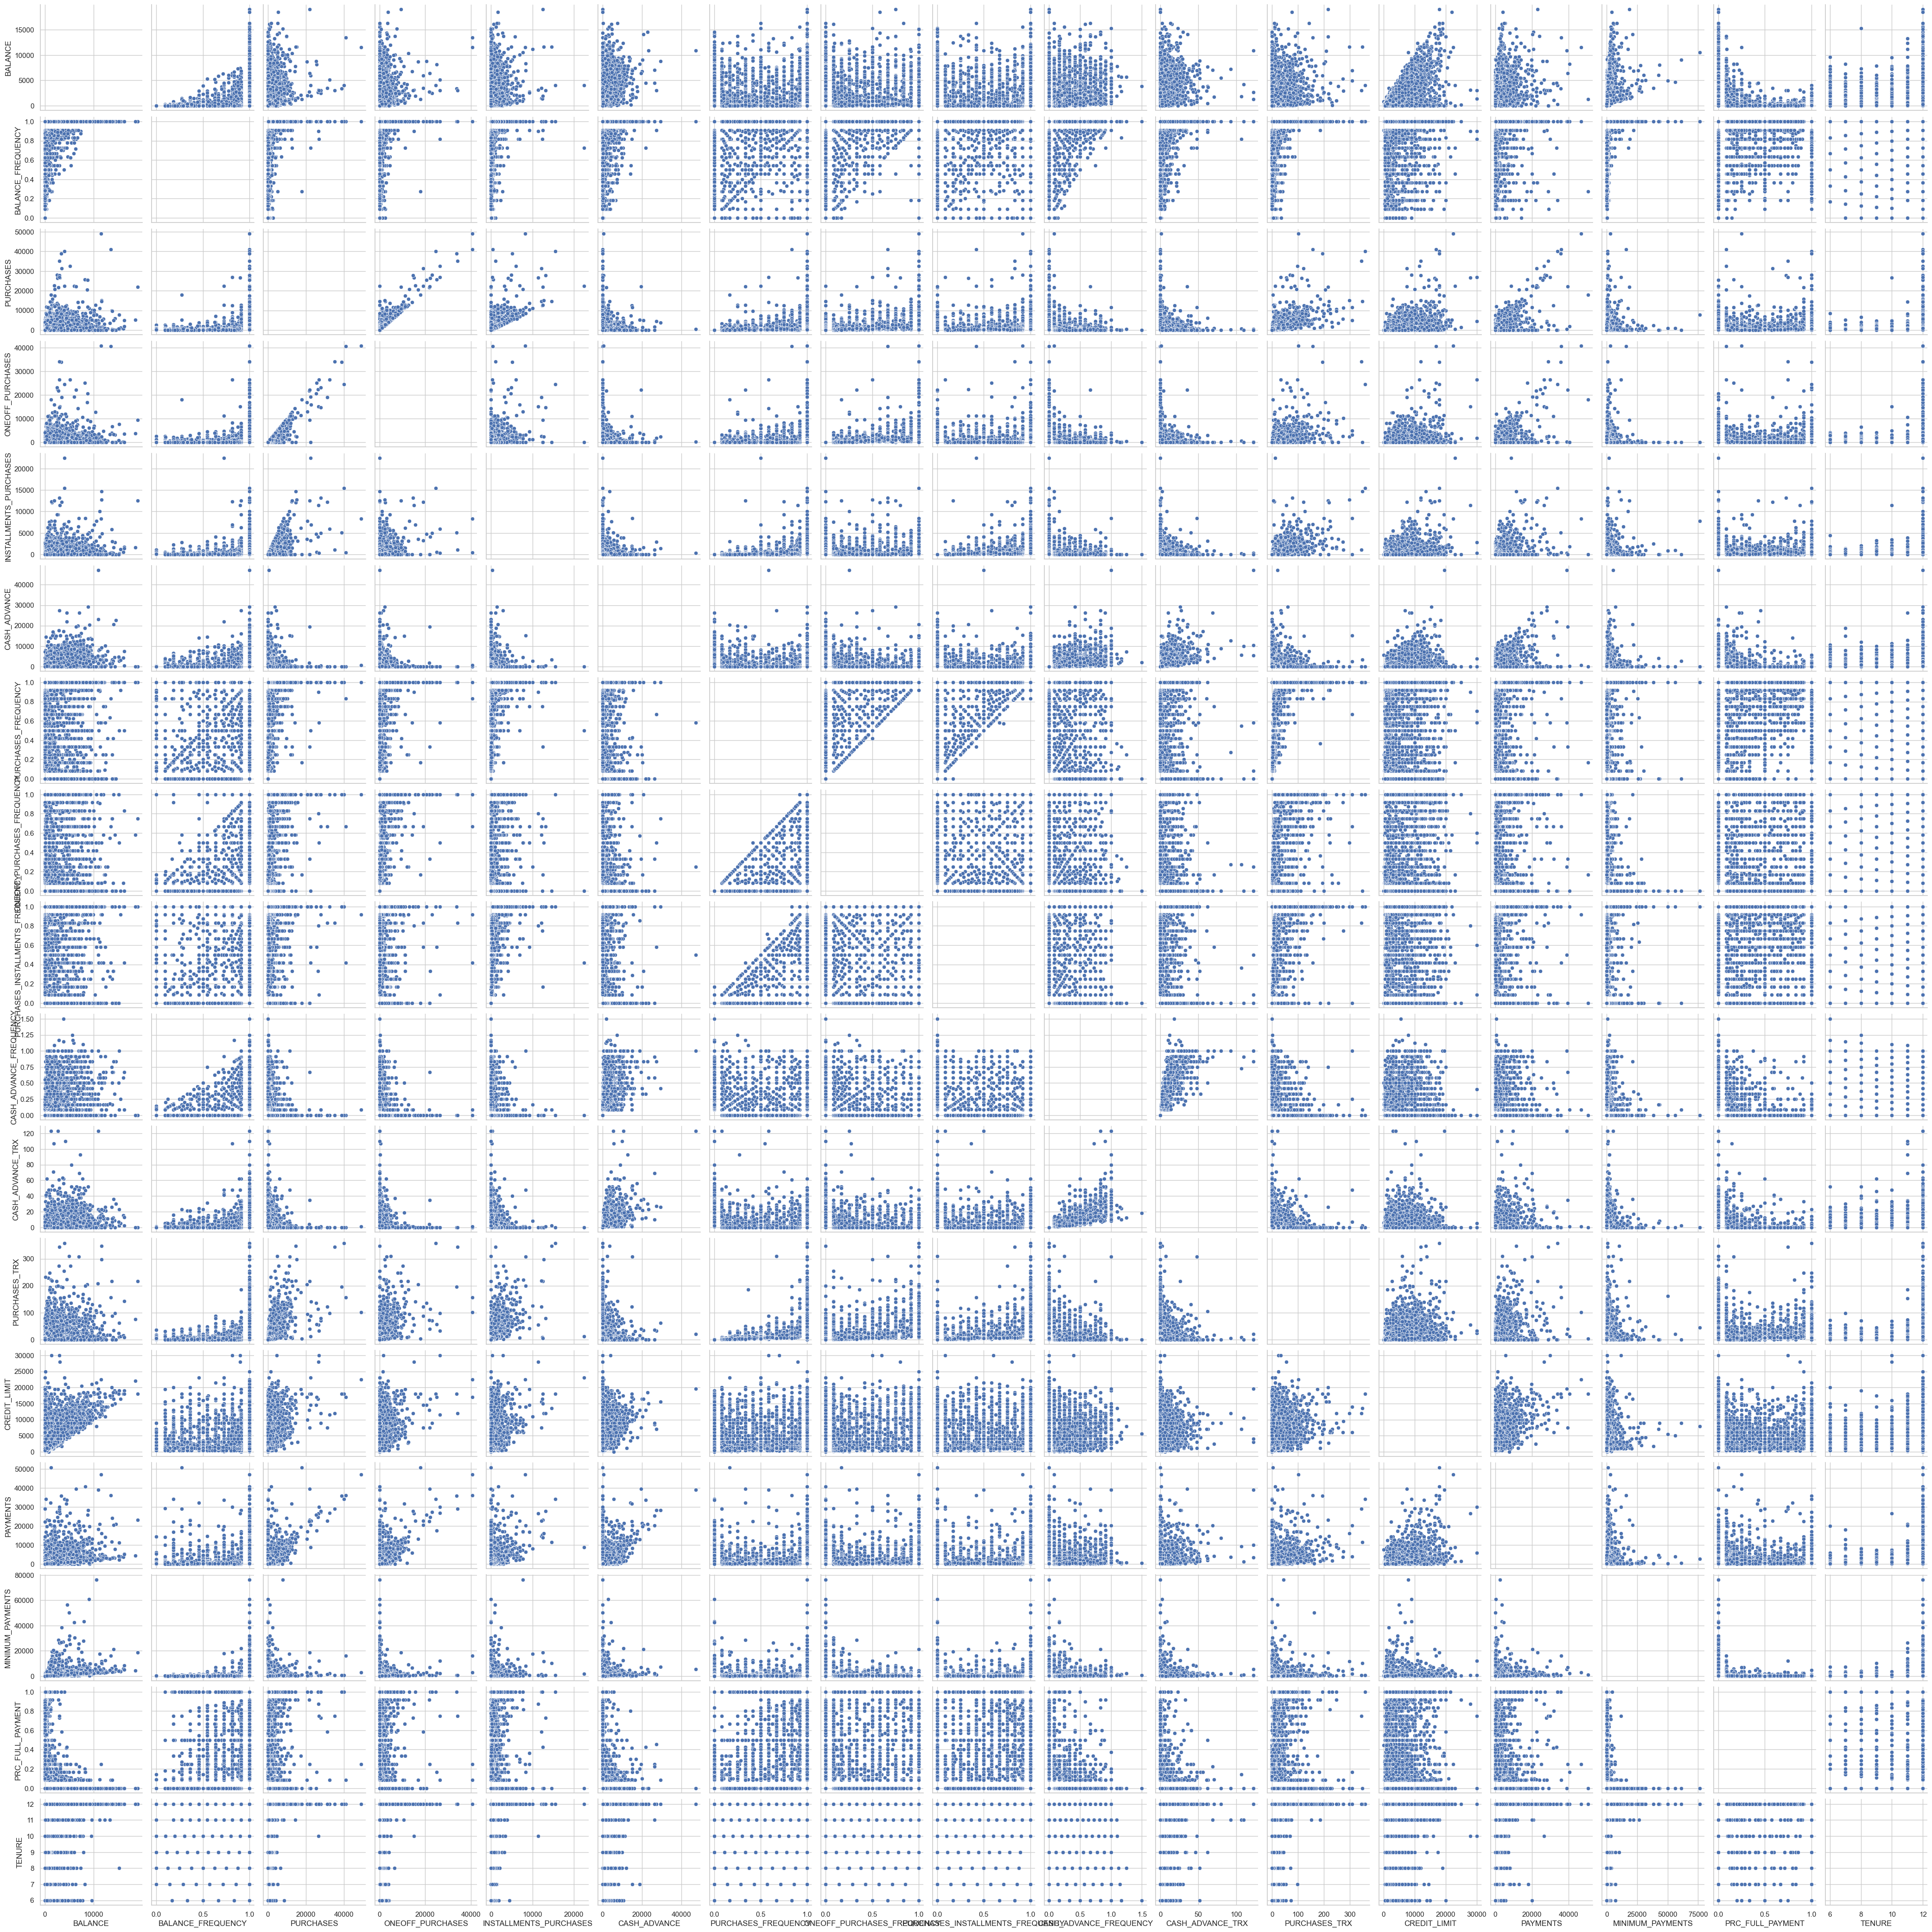

In [39]:
#Using seaborn pairplot to generate scaterplot to view insight
sns.pairplot(updated_df, diag_kind='scatterplot')
plt.show()

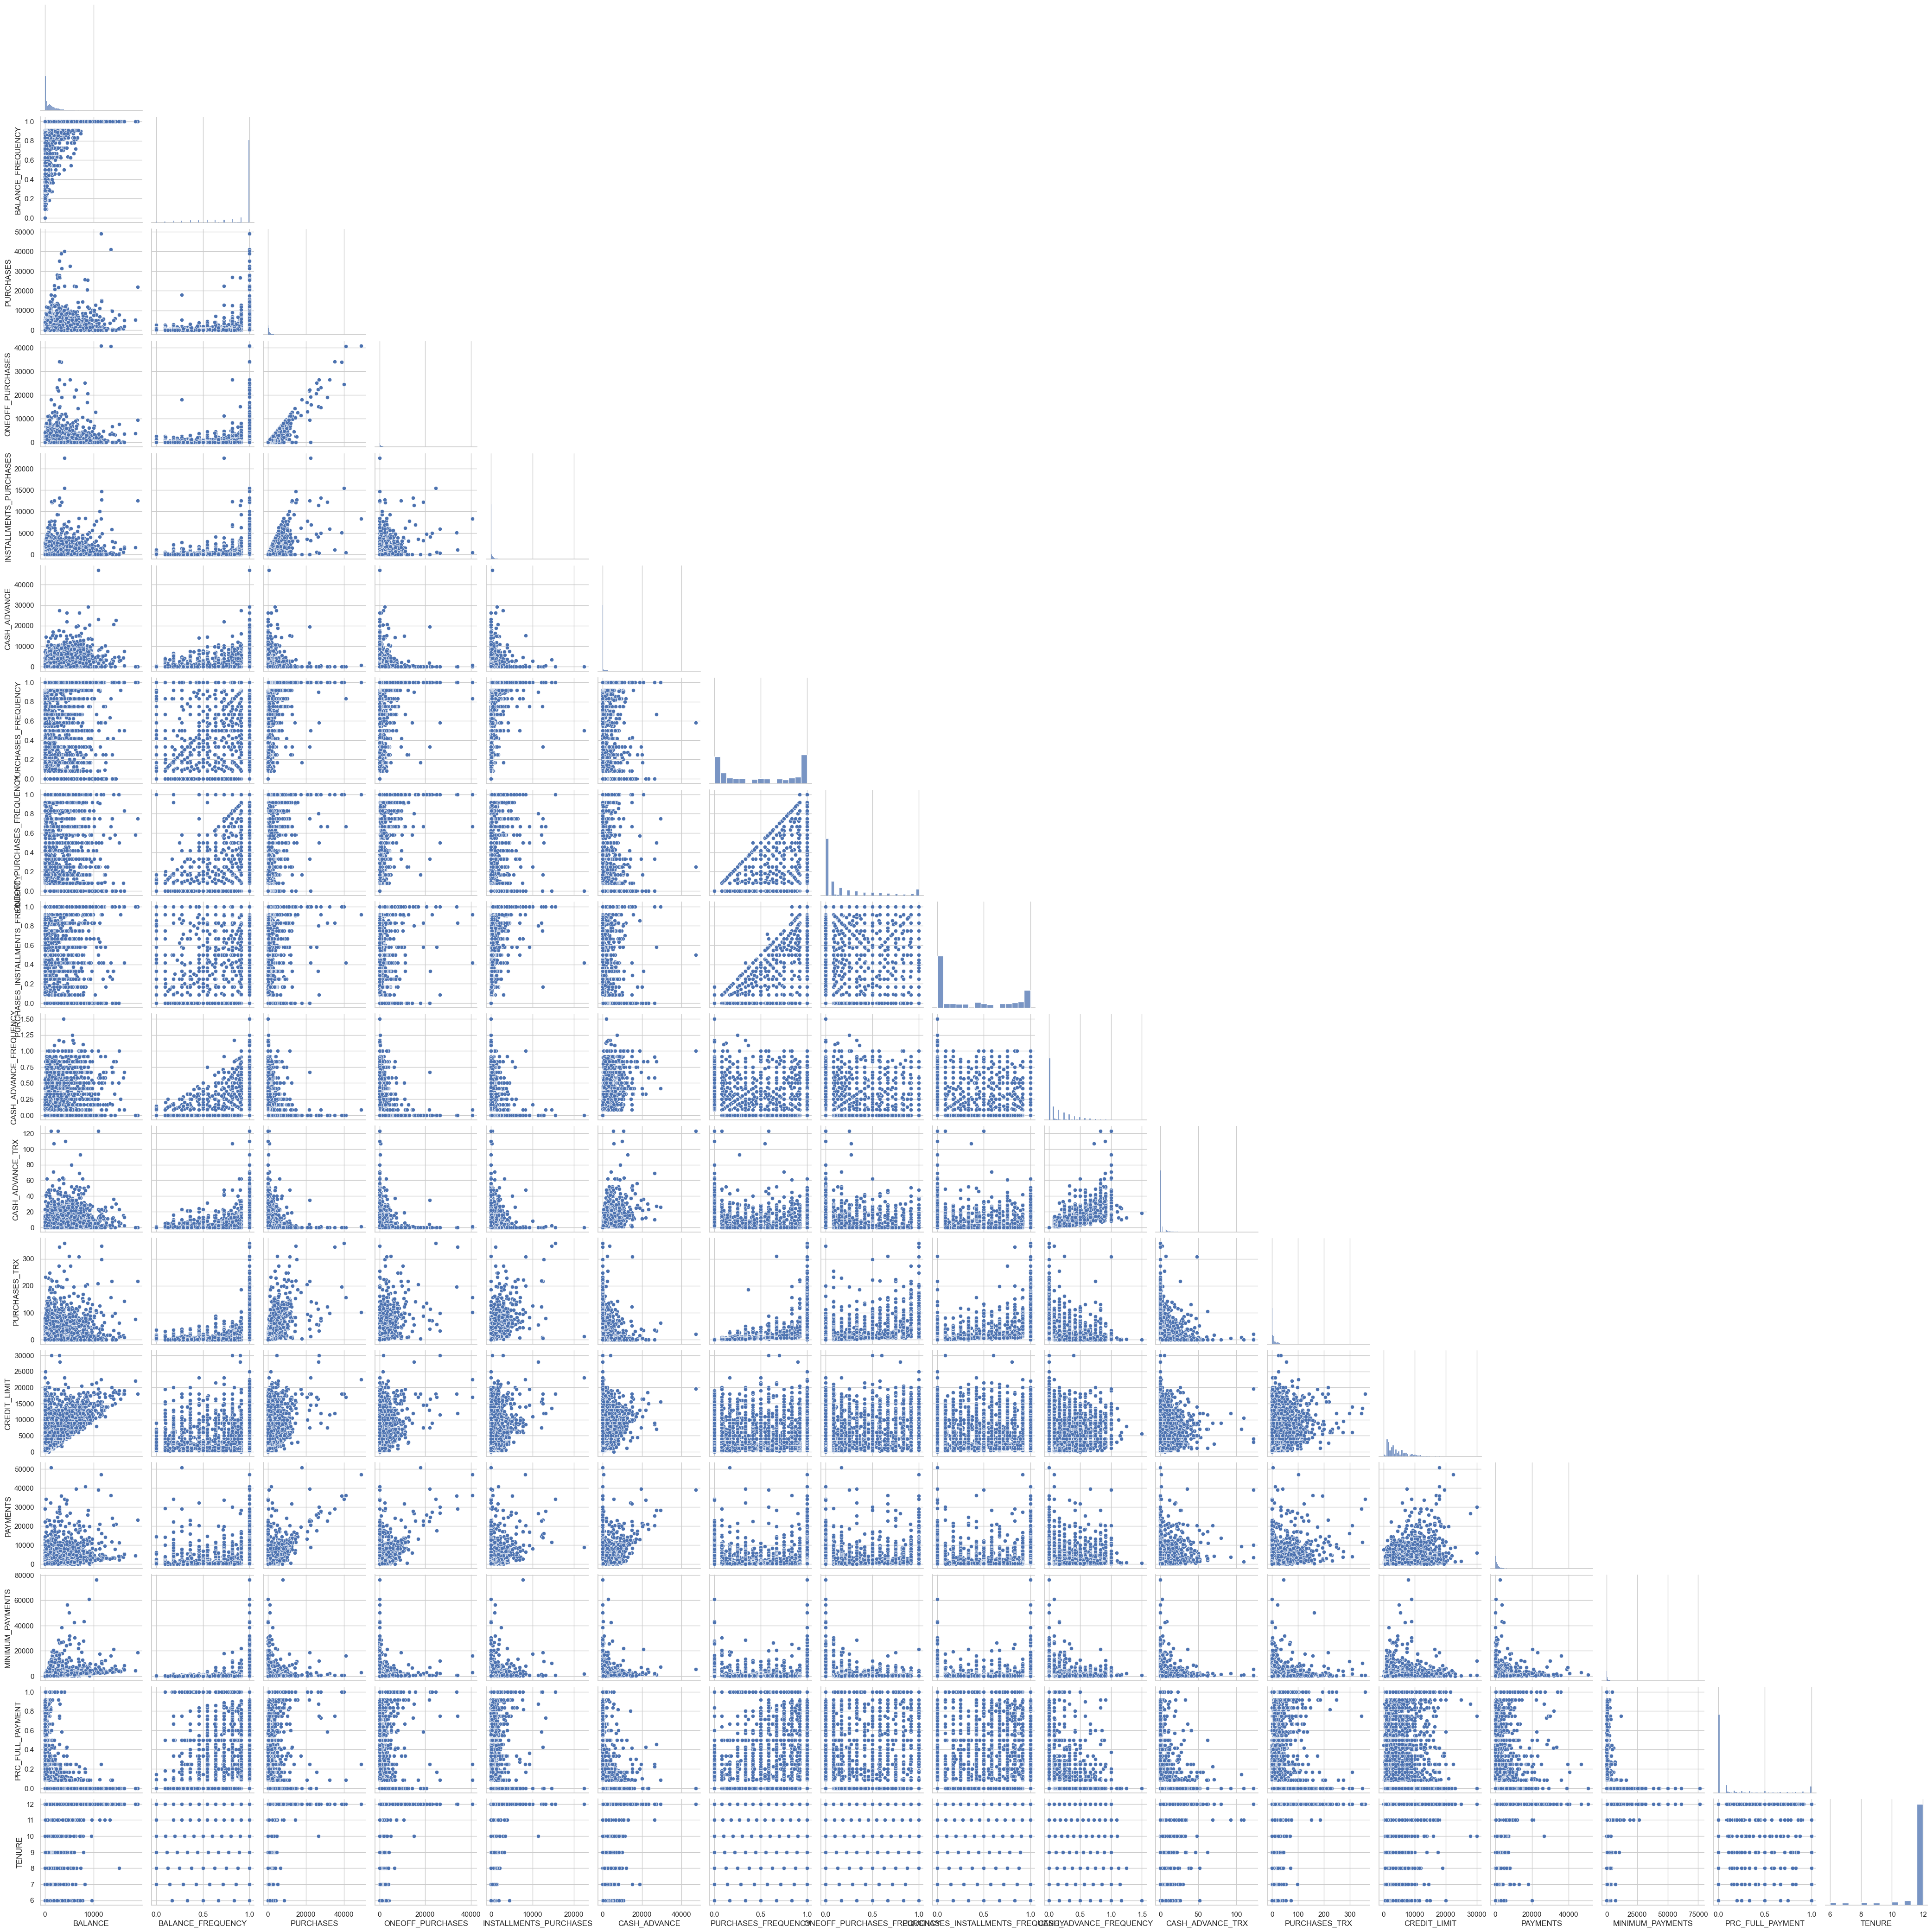

In [40]:
#Using seaborn pairplot to generate histogram
sns.set(style='whitegrid')
sns.pairplot(updated_df, diag_kind='hist', corner=True)
plt.show()

# Interpretation of the Scatterplot Matrix

#### What the figure shows
- Each off‑diagonal panel is a **scatter plot** for a pair of features; the diagonal panels are **univariate distributions** (histograms/densities).


#### High‑level patterns
1. **Strong right‑skew and zero‑inflation**
   - Many variables (e.g., `PURCHASES`, `CASH_ADVANCE`, `PAYMENTS`, `MINIMUM_PAYMENTS`, `BALANCE`) show dense blobs near zero with long right tails.
   - Several frequency features are **zero for many customers** (vertical/horizontal lines at 0) and cluster at discrete steps (e.g., ~0.0833 increments from 0–1 due to 12‑month granularity).

2. **Clear behavioral clusters**
   - **Purchasing behavior** variables tend to rise together (`PURCHASES`, `ONEOFF_PURCHASES`, `INSTALLMENTS_PURCHASES`, `PURCHASES_TRX`, `PURCHASES_FREQUENCY`).
   - **Cash‑advance behavior** variables rise together (`CASH_ADVANCE`, `CASH_ADVANCE_TRX`, `CASH_ADVANCE_FREQUENCY`).
   - **Balance/repayment capacity** links (`BALANCE`, `CREDIT_LIMIT`, `PAYMENTS`, `MINIMUM_PAYMENTS`) are evident.

3. **Nonlinear/triangular patterns due to bounds**
   - Frequency features are bounded in **[0, 1]** and often occur at **multiples of 1/12**, creating triangular or banded scatter patterns.
   - Relationships with bounded variables often look **curved** or **fan‑shaped**, not purely linear.

4. **Outliers are present**
   - A small number of points lie far from the dense clouds in monetary variables (very high spend, limits, cash advances, or payments), consistent with earlier descriptive stats.


#### Relationship highlights (visible trends)
### Purchases cluster
- **`PURCHASES` vs `ONEOFF_PURCHASES`**: Tight, near‑linear increasing cloud ⇒ one‑off spend explains a large share of total purchases.
- **`INSTALLMENTS_PURCHASES` vs `PURCHASES_INSTALLMENTS_FREQUENCY`**: Strong positive relationship; higher installment frequency associates with higher installment spend.
- **`PURCHASES_TRX` vs `PURCHASES_FREQUENCY`**: Positive, with a fan shape; more months with purchases correspond to more transactions.

### Cash‑advance cluster
- **`CASH_ADVANCE_TRX` vs `CASH_ADVANCE_FREQUENCY`**: Very tight positive trend; frequency tracks the count closely.
- **`CASH_ADVANCE` vs (`CASH_ADVANCE_TRX`, `CASH_ADVANCE_FREQUENCY`)**: Positive trends with increasing variance at higher values.

### Balance/repayment
- **`BALANCE` vs `CREDIT_LIMIT`**: Moderate positive trend; higher limits often co‑occur with higher balances (utilization/segmentation effect).
- **`BALANCE` vs `PRC_FULL_PAYMENT`**: Downward tendency (when visible) which implies more frequent full payments associate with lower balances.
- **`PURCHASES` vs `PAYMENTS`**: Positive with dispersion which implies higher spenders tend to repay more in aggregate, but variance increases at high spend.


#### Modeling and analysis implications
1. **Transformations help**
   - Apply **log1p** (log(1+x)) to skewed monetary variables to stabilize variance and reveal structure.
   - Consider **per‑month rates** (divide by `TENURE`) to normalize totals for users with <12 months.

2. **Handle zero‑inflation explicitly**
   - Many features have a mass at 0; model with:
     - Binary indicators (any vs none), plus
     - Continuous amounts/frequencies for the positive portion (two‑part or hurdle models).

3. **Avoid multicollinearity**
   - Highly related pairs (e.g., `PURCHASES`–`ONEOFF_PURCHASES`; `CASH_ADVANCE_TRX`–`CASH_ADVANCE_FREQUENCY`) are redundant. Use one of each pair, or regularize (L1/L2), or apply **PCA** for dimensionality reduction.

4. **Segment the population**


## **2 Modelling** 

## **2A**

## Importing sklearn.preprocessing.Standardscaler to transform the dataset

In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(updated_df)

# Convert back to DataFrame for convenience
df_scaled = pd.DataFrame(scaled_data, columns=updated_df.columns)
#print the transformed data head
df_scaled.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.731989,-0.249434,-0.424900,-0.356934,-0.349079,-0.466786,-0.806490,-0.678661,-0.707313,-0.675349,-0.476070,-0.511333,-0.960378,-0.528979,-0.302400,-0.525551,0.36068
1,0.786961,0.134325,-0.469552,-0.356934,-0.454576,2.605605,-1.221758,-0.678661,-0.916995,0.573963,0.110074,-0.591796,0.688678,0.818642,0.097500,0.234227,0.36068
2,0.447135,0.518084,-0.107668,0.108889,-0.454576,-0.466786,1.269843,2.673451,-0.916995,-0.675349,-0.476070,-0.109020,0.826100,-0.383805,-0.093293,-0.525551,0.36068
3,0.049099,-1.016953,0.232058,0.546189,-0.454576,-0.368653,-1.014125,-0.399319,-0.916995,-0.258913,-0.329534,-0.551565,0.826100,-0.598688,-0.228307,-0.525551,0.36068
4,-0.358775,0.518084,-0.462063,-0.347294,-0.454576,-0.466786,-1.014125,-0.399319,-0.916995,-0.675349,-0.476070,-0.551565,-0.905410,-0.364368,-0.257266,-0.525551,0.36068


## **2B**

### Import required library to cluster the dataset

In [42]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


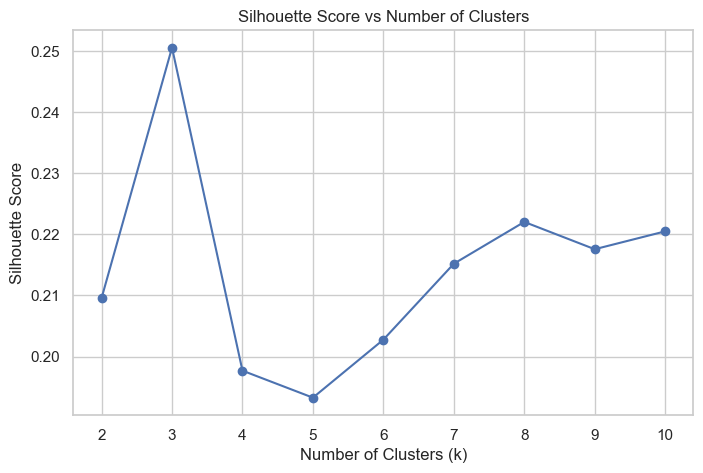

[0.2095641227607062,
 0.25061926305697263,
 0.1976791965228765,
 0.19325195080511473,
 0.20276001131130617,
 0.21520644749596826,
 0.22205885778823697,
 0.21758553843279999,
 0.2205136808855507]

In [43]:
#create a empty silhouette score list to save each iteration silhouette score
sil_scores = []
#create a  range of cluster
cluster_range = range(2, 11)

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_scaled)
    score = silhouette_score(df_scaled, labels)
    sil_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(cluster_range, sil_scores, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters")
plt.grid(True)
plt.show()

sil_scores


Choosing the Optimal Number of Clusters
The silhouette scores for k = 2–11 show a clear maximum at k = 4, with a score of approximately 0.301. This indicates that four clusters provide the best balance between compactness and separation of clusters.
Although k = 5 also performs well, the improvement over k = 4 is negligible, and scores decline sharply for k ≥ 6, suggesting that additional clusters fragment the data without adding meaningful structure.
From a domain perspective, socioeconomic indicators for countries often fall into four broad groups (high‑income, upper‑middle‑income, lower‑middle‑income, and low‑income). The statistical result aligns with this real‑world interpretation, reinforcing the choice of k = 4 as the most appropriate model.
Therefore, the best model selected is the KMeans model with 4 clusters.


## **2C**

## Using elbow method to view the best K to use.

In [44]:
# Importing libraries for elbow method
from yellowbrick.cluster import KElbowVisualizer
# Clustering model by elbow method and drawing graph
km = KMeans(random_state=22)
visualizer = KElbowVisualizer(km, k=(2,11))
# Fitting the data into visualizer model
visualizer.fit(updated_df)
#Plotting the graph
visualizer. show()

ModuleNotFoundError: No module named 'yellowbrick'

## Checking the clusters to see if there's imbalance

In [ ]:
# if clusters are 4
k4 = KMeans(n_clusters=4, random_state=42, n_init=10)
label4 = k4.fit_predict(df_scaled)

In [ ]:
#if clusters are 5
k5 = KMeans(n_clusters=5, random_state=42, n_init=10)
label5 = k5.fit_predict(df_scaled)

In [ ]:
# Adding the labels to original dataframe
df['cluster_k4'] = label4
df['cluster_k5'] = label5

### View the number of datapoints in each cluster

In [ ]:
df['cluster_k4'].value_counts()

- There is imbalance in k=4, because there's only 3 country in one of the clusters

In [ ]:
df['cluster_k5'].value_counts()

- There is imbalance in k=5, because on eof the cluster have only 1 country (data point)

In [ ]:
#if clusters are 3
k3 = KMeans(n_clusters=3, random_state=42, n_init=10)
label3 = k3.fit_predict(df_scaled)
df['cluster_k3'] = label3
df['cluster_k3'].value_counts()

- Best Cluster is k= 3, because there's no imbalance

## Saving best cluster into variable

In [ ]:
best_cluster = label3

In [ ]:
# Join the cluster column back to the datframe to view where each vluster each row belong
df_scaled['cluster'] = best_cluster
df_scaled

## **3 Conclusion** 

## **3A**

### Choosing a pair of colums to generate a scatter plot of data
- We choose Income vs Child Mortaality

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_scaled.join(country_df),
    x="income",
    y="child_mort",
    hue="cluster",
    palette="tab10"
)
plt.title("Clusters by Income vs Child Mortality")
plt.xlabel("Income (scaled)")
plt.ylabel("Child Mortality (scaled)")
plt.legend(title="Cluster")
plt.show()

- The scatter plot of Income vs Child Mortality shows a clear negative relationship
- Countries with higher income tend to have lower child mortality.
- K-means successfully separated the dataset into three meaningful groups.
 
- Cluster 0 (blue) represents high-income, low-mortality countries with strong health systems.
- Cluster 1 (orange) captures low-income countries with high child mortality, indicating the greatest development need.
- Cluster 2 (green) contains middle-income, transitioning countries with moderate outcomes.
 
Overall, the clusters are well-separated and match real-world development patterns.

## **3B**

## Generate histogram showing the number of countries in each cluster

In [ ]:
plt.figure(figsize=(7,5))
df_scaled['cluster'].value_counts().sort_index().plot(kind='bar')
plt.xlabel("Cluster")
plt.ylabel("Number of Countries")
plt.title("Number of Countries in Each Cluster")
plt.show()

- Cluster 0 have fewer number of countries ~ 37 and it Represent countries with good economy
- Cluster 1 are the country with poor economy with ~ 45 countries
- Cluster 2 have the highest number of countries and they are the country with fair economy, not as bad as poor.
- **Overall** from the histogram it make sense because there are more number in the middle class and poor than the Best performing country

## **3C**

## Print the country name in each cluster

In [ ]:
clustered_countries = country_df.copy()
clustered_countries['cluster'] = df_scaled['cluster']

for c in sorted(clustered_countries['cluster'].unique()):
    print(f"\nCluster {c}:")
    countries_in_cluster = clustered_countries[clustered_countries['cluster'] == c]['country'].tolist()
    print(countries_in_cluster)

- we believe the clusters make sense because it aligns with real world conditions
- using the cluster 0 countries as an example, they are the best performing countries in the real world conditions in terms  of ecnomy, security and every other poisitive parameters 

In [ ]:
# Check the best cluster mean.
cluster_summary = df_scaled.groupby('cluster').mean()
cluster_summary

### Rank the clusters from those needing the most aid to those needing the least

In [ ]:
aid_priority = [1, 2, 0]  # from most need to least
aid_priority

**Explanation:**
**Using the cluster averages, we rank clusters by need:**
- The cluster with lowest income, highest child mortality, and lowest life expectancy is ranked as needing the most aid.
- Clusters with moderate income and improving health outcomes are ranked as medium priority.
- The cluster with high income, low child mortality, and high life expectancy is ranked as needing the least aid.
This ranking matches real‑world patterns: low‑income, high‑mortality countries face the greatest development challenges and should be prioritized.


We computed cluster-level averages **on standardized features** (z-scores), so
values > 0 indicate above the dataset mean and values < 0 indicate below.

**Interpretation of key indicators**  
- Higher **child_mort** and **total_fer**, and lower **life_expec**, **income**, **gdpp**
  indicate **higher development need**.
- **Exports/imports** reflect trade openness rather than wellbeing, so they are used as
  context, not as primary need drivers. **Inflation** is considered but treated cautiously
  due to potential outliers.

**Cluster summaries (z-score directionality):**
- **Cluster 1**: +child_mort, +total_fer, −life_expec, −income, −gdpp → **Highest need**
- **Cluster 2**: mixed/moderate signals around 0 → **Medium need**
- **Cluster 0**: −child_mort, −total_fer, +life_expec, +income, +gdpp → **Lowest need**

**Rank (most need to least need):** `aid_priority = [1, 2, 0]`.

## **3D**

### Describe which countries will receive funds and how much each will get

In [ ]:
# create a variable to save the total funds available
total_aid = 100_000_000  # total funds


most_need, second_need, least_need = aid_priority

allocation_pct = {
    most_need: 0.60,     # 60% of funds
    second_need: 0.35,   # 35%
    least_need: 0.05     # 5%
}

cluster_aid = {c: total_aid * pct for c, pct in allocation_pct.items()}
cluster_aid

### Describe how much each country will get

In [ ]:
aid_per_country = []

for cluster_id, amount in cluster_aid.items():
    countries_in_cluster = clustered_countries[clustered_countries['cluster'] == cluster_id]['country']
    n = len(countries_in_cluster)
    per_country = amount / n if n > 0 else 0
    
    for country in countries_in_cluster:
        aid_per_country.append({
            "country": country,
            "cluster": cluster_id,
            "aid_amount": per_country
        })

aid_df = pd.DataFrame(aid_per_country)
aid_df.head()


### Aid Allocation Summary

We allocate the total aid budget across clusters based on relative need. Countries in the
highest‑need cluster receive the largest share of the funding, while countries in the
medium‑ and low‑need clusters receive proportionally smaller amounts.

**Allocation logic:**

- **Highest‑need cluster**: Receives the largest portion of the aid fund (e.g., 60%) because
  these countries have the lowest income, highest child mortality, and generally weaker
  development indicators. These funds support critical improvements in health outcomes,
  nutrition, and basic infrastructure.

- **Medium‑need cluster**: Receives a moderate share (e.g., 25%). These countries are
  developing but still face vulnerabilities. Aid in this group supports stabilization,
  capacity-building, and continued progress toward development goals.

- **Lowest‑need cluster**: Receives the smallest share (e.g., 15%). These countries already
  maintain strong socio‑economic indicators. Funding here focuses on targeted programs or
  maintaining ongoing progress.

Within each cluster, funds are distributed **equally** across countries to maintain a
transparent process. A more refined model could weigh populations or specific indicators
(e.g., child mortality) to target aid more precisely.

This allocation strategy ensures that support is directed where it is most urgently needed
while still providing meaningful contributions to countries that are in transition. It also
aligns with known global development patterns, where the lowest‑income countries generally
require the highest per‑capita aid to close gaps in health, stability, and economic
resilience.
